# PatchCore WRN50 Threshold Policies

This notebook is for choosing a better operating policy for the WideResNet50-2 PatchCore run on the labeled `120k / 10k / 20k` split.

What it covers:

- single-threshold policies for reducing false negatives or false defect calls
- a validation-F1 operating point
- a recall-floor operating point
- a false-positive-rate cap operating point
- a two-threshold `auto-normal / review / auto-anomaly` policy that can reduce both kinds of automatic mistakes by routing uncertain wafers to review

Important constraint:

A single threshold usually trades false negatives against false positives. If we want to reduce **both** kinds of automatic mistakes at the same time, we generally need either:

- a better ranking model, or
- a gray-zone / review policy with two thresholds


In [1]:
from pathlib import Path
import sys

NOTEBOOK_ROOT = Path.cwd().resolve()
if str(NOTEBOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from helpers.patchcore_threshold_tools import (
    build_review_policy_summary,
    build_single_threshold_policy_table,
    build_threshold_sweep,
    load_variant_artifacts,
)


def resolve_project_root(start: Path | None = None) -> Path:
    start_path = (start or Path.cwd()).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'notebooks').exists() and (candidate / 'outputs').exists():
            return candidate
    raise FileNotFoundError('Could not locate the project root.')


PROJECT_ROOT = resolve_project_root()
BUNDLE_DIR = PROJECT_ROOT / 'outputs' / 'modal_runs' / 'patchcore_wrn50_120k_20260320' / 'patchcore_wrn50_multilayer_120k_5pct'
VARIANT_NAME = 'topk_mb50k_r005'

MIN_RECALL = 0.70
MAX_FALSE_POSITIVE_RATE = 0.03
MAX_AUTO_NORMAL_ANOMALY_RATE = 0.01
MIN_AUTO_ANOMALY_PRECISION = 0.60


In [2]:
summary, val_scores_df, test_scores_df = load_variant_artifacts(BUNDLE_DIR, VARIANT_NAME)
current_threshold = float(summary['threshold'])

run_overview_df = pd.DataFrame([
    {
        'variant': VARIANT_NAME,
        'current_threshold': current_threshold,
        'current_test_precision': float(summary['precision']),
        'current_test_recall': float(summary['recall']),
        'current_test_f1': float(summary['f1']),
        'current_test_fp': int(summary['metrics_at_validation_threshold']['confusion_matrix'][0][1]),
        'current_test_fn': int(summary['metrics_at_validation_threshold']['confusion_matrix'][1][0]),
    }
])

display(run_overview_df.round(4))


,variant,current_threshold,current_test_precision,current_test_recall,current_test_f1,current_test_fp,current_test_fn
0,topk_mb50k_r005,0.5598,0.4206,0.712,0.5288,981,288


In [3]:
single_threshold_df = build_single_threshold_policy_table(
    val_scores_df,
    test_scores_df,
    current_threshold=current_threshold,
    min_recall=MIN_RECALL,
    max_false_positive_rate=MAX_FALSE_POSITIVE_RATE,
)

single_threshold_df.sort_values('test_f1', ascending=False).reset_index(drop=True).round(4)


,policy,threshold,val_precision,val_recall,val_f1,val_false_positive_rate,test_precision,test_recall,test_f1,test_false_positive_rate,test_predicted_anomalies,test_tp,test_fp,test_tn,test_fn
0,validation_f1,0.5713,0.5091,0.616,0.5575,0.0313,0.5147,0.612,0.5592,0.0304,1189,612,577,18423,388
1,fp_cap_3.00%,0.5728,0.5137,0.600,0.5535,0.0299,0.5180,0.591,0.5521,0.0289,1141,591,550,18450,409
2,current_threshold,0.5598,0.4207,0.690,0.5227,0.0500,0.4206,0.712,0.5288,0.0516,1693,712,981,18019,288
3,recall_floor_0.70,0.5587,0.4103,0.700,0.5174,0.0529,0.4105,0.725,0.5242,0.0548,1766,725,1041,17959,275


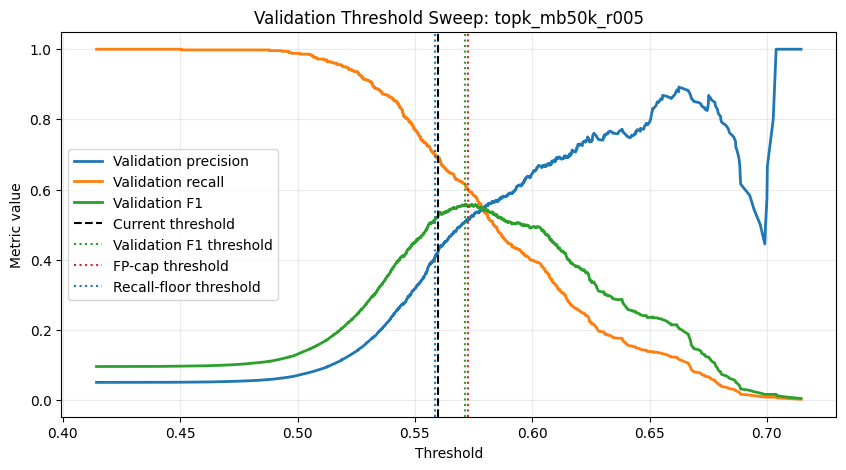

In [4]:
val_sweep_df = build_threshold_sweep(val_scores_df)
validation_f1_threshold = float(single_threshold_df.loc[single_threshold_df['policy'] == 'validation_f1', 'threshold'].iloc[0])
fp_cap_threshold = float(single_threshold_df.loc[single_threshold_df['policy'] == f'fp_cap_{MAX_FALSE_POSITIVE_RATE:.2%}', 'threshold'].iloc[0])
recall_floor_threshold = float(single_threshold_df.loc[single_threshold_df['policy'] == f'recall_floor_{MIN_RECALL:.2f}', 'threshold'].iloc[0])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(val_sweep_df['threshold'], val_sweep_df['precision'], label='Validation precision', linewidth=2)
ax.plot(val_sweep_df['threshold'], val_sweep_df['recall'], label='Validation recall', linewidth=2)
ax.plot(val_sweep_df['threshold'], val_sweep_df['f1'], label='Validation F1', linewidth=2)
ax.axvline(current_threshold, color='black', linestyle='--', linewidth=1.5, label='Current threshold')
ax.axvline(validation_f1_threshold, color='tab:green', linestyle=':', linewidth=1.5, label='Validation F1 threshold')
ax.axvline(fp_cap_threshold, color='tab:red', linestyle=':', linewidth=1.5, label='FP-cap threshold')
ax.axvline(recall_floor_threshold, color='tab:blue', linestyle=':', linewidth=1.5, label='Recall-floor threshold')
ax.set_title(f'Validation Threshold Sweep: {VARIANT_NAME}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Metric value')
ax.legend(loc='best')
ax.grid(alpha=0.25)
plt.show()


In [5]:
review_policy_df = build_review_policy_summary(
    val_scores_df,
    test_scores_df,
    max_auto_normal_anomaly_rate=MAX_AUTO_NORMAL_ANOMALY_RATE,
    min_auto_anomaly_precision=MIN_AUTO_ANOMALY_PRECISION,
)

review_policy_df.round(4)


,policy,low_threshold,high_threshold,target_max_auto_normal_anomaly_rate,target_min_auto_anomaly_precision,val_auto_normal_count,val_auto_normal_anomaly_rate,val_auto_normal_npv,val_auto_anomaly_count,val_auto_anomaly_precision,...,test_auto_fn,test_auto_tp,test_auto_fp,test_review_count,test_review_rate,test_review_anomalies,test_review_normals,test_resolved_count,test_resolved_rate,test_automatic_error_count
0,review_band,0.544,0.593,0.01,0.6,8453,0.0099,0.9901,360,0.6,...,176,417,287,2395,0.1198,407,1988,17605,0.8802,463


In [6]:
best_f1_row = single_threshold_df.loc[single_threshold_df['policy'] == 'validation_f1'].iloc[0]
recall_row = single_threshold_df.loc[single_threshold_df['policy'] == f'recall_floor_{MIN_RECALL:.2f}'].iloc[0]
review_row = review_policy_df.iloc[0]

message = f"""
### Working Guidance

- **Reduce false negatives:** use the recall-floor threshold near `{recall_row['threshold']:.6f}`. On the saved test split it reaches recall `{recall_row['test_recall']:.3f}`, but false positives rise to `{int(recall_row['test_fp'])}`.
- **Reduce false defect calls:** use the FP-capped or validation-F1 threshold. The validation-F1 threshold `{best_f1_row['threshold']:.6f}` cuts test false positives to `{int(best_f1_row['test_fp'])}` and lifts test F1 to `{best_f1_row['test_f1']:.3f}`.
- **Reduce both kinds of automatic mistakes:** use the review band. With the current defaults, scores below `{review_row['low_threshold']:.6f}` are auto-normal, scores at or above `{review_row['high_threshold']:.6f}` are auto-anomaly, and the middle goes to review.
- With that review band on the saved test split, auto-normal wafers have anomaly rate `{review_row['test_auto_normal_anomaly_rate']:.3%}`, auto-anomaly wafers have precision `{review_row['test_auto_anomaly_precision']:.3%}`, and `{review_row['test_review_rate']:.2%}` of wafers go to review.
"""

display(Markdown(message))



### Working Guidance

- **Reduce false negatives:** use the recall-floor threshold near `0.558741`. On the saved test split it reaches recall `0.725`, but false positives rise to `1041`.
- **Reduce false defect calls:** use the FP-capped or validation-F1 threshold. The validation-F1 threshold `0.571337` cuts test false positives to `577` and lifts test F1 to `0.559`.
- **Reduce both kinds of automatic mistakes:** use the review band. With the current defaults, scores below `0.543997` are auto-normal, scores at or above `0.593031` are auto-anomaly, and the middle goes to review.
- With that review band on the saved test split, auto-normal wafers have anomaly rate `1.041%`, auto-anomaly wafers have precision `59.233%`, and `11.97%` of wafers go to review.
